<a href="https://colab.research.google.com/github/fatimahK-cyber/Smoke-Detection/blob/main/Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Smoke Detection Database





This project uses a Smoke Detection IoT sensor dataset obtained from Kaggle, which includes environmental data such as temperature, humidity, gas concentration, and air pressure. The dataset is labeled with a fire alarm indicator (0 = no fire, 1 = fire), making it suitable for supervised machine learning. It is used to apply KNN and Random Forest algorithms in order to analyze and compare their effectiveness in accurately predicting fire detection, supporting the development of more reliable and intelligent IoT-based safety systems.

### 1. Import Libraries and Load the Dataset

In [ ]:
# Import necessary libraries
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score, auc)

### Dataset Information
**Room Occupancy detection data (IoT sensor)**  
https://www.kaggle.com/datasets/kukuroo3/room-occupancy-detection-data-iot-sensor

Person detection in an embedded IoT device without the use of a computer vision solution refers to the ability to detect the presence of a person in a given environment using sensors and signal processing techniques instead of relying on visual image analysis.​Typically, this type of person detection solution is achieved by leveraging various types of sensors, such as passive infrared (PIR) sensors, ultrasonic sensors, and radar sensors, which can detect physical changes in the environment caused by the presence of a person, such as body heat or movement.​Signal processing techniques are then applied to the sensor data to detect and differentiate the signal patterns associated with a person's presence from other environmental noise. Machine learning algorithms may also be used to improve the accuracy of the person detection system.​By using sensors and signal processing techniques, this type of person detection system can be implemented in an embedded IoT device with limited computing resources, making it suitable for a wide range of applications, such as home automation, security systems, and smart buildings.​​

**Available Features (collected from IoT sensors)**:

| Feature Name         | Description                                 | Example Value              |
|----------------------|---------------------------------------------|----------------------------|
| date                 | Date and Time of Sensor Reading             | 2015-02-02 14:19:00        |
| Temperature          | Temperature in Celsius                      | 23.7                       |
| Humidity             | Relative Humidity in %                      | 26.27                      |
| Light                | Light Level (Lux)                           | 585.2                      |
| CO2                  | CO2 concentration in ppm                    | 749.2                      |
| HumidityRatio        | Ratio of humidity in the air                 | 0.004764                   |
| Occupancy            | Indicator if room is occupied (1 for Yes, 0 for No) | 1                         |



In [ ]:

# Read the dataset directly from the Google Drive folder
# The dataset has already been downloaded from the Kaggle website and uploaded to the Google Drive folder

URL = 'https://drive.google.com/file/d/14RtnpEO948_X3MVHKHer8-yS38tHGpuM/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+URL.split('/')[-2]

# Load the dataset from Google Drive
df = pd.read_csv(path)

In [ ]:
# Display the first five rows of the DataFrame to understand its structure
df.head()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


### 2. Exploratory Data Analysis (EDA) Using Pandas

In [ ]:
# Print basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [ ]:
# Get a statistical summary of the dataset
df.describe()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62630.000000,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,31314.500000,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,18079.868017,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,0.000000,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15657.250000,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,31314.500000,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,46971.750000,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,62629.000000,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


In [ ]:
# Check for missing values (if any)
df.isnull().sum()

,0
Unnamed: 0,0
UTC,0
Temperature[C],0
Humidity[%],0
TVOC[ppb],0
eCO2[ppm],0
Raw H2,0
Raw Ethanol,0
Pressure[hPa],0
PM1.0,0


In [ ]:
# compare the count of Fire Alarm and no Fire Alarm
df["Fire Alarm"].value_counts()

,count
Fire Alarm,
1,44757
0,17873


<Axes: xlabel='Fire Alarm', ylabel='count'>

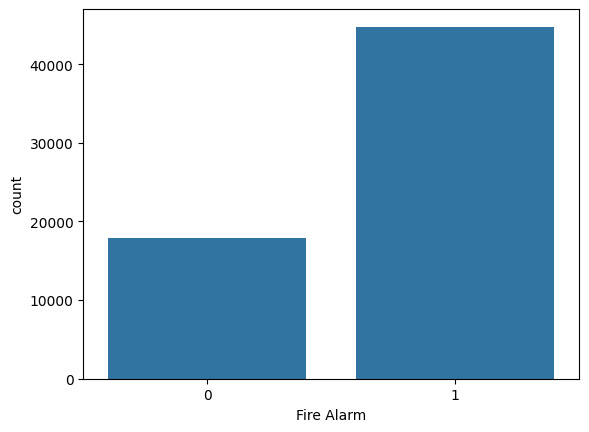

In [ ]:
# Visualize the count of Fire Alarm and No Fire Alarm
sns.countplot(x="Fire Alarm", data=df)

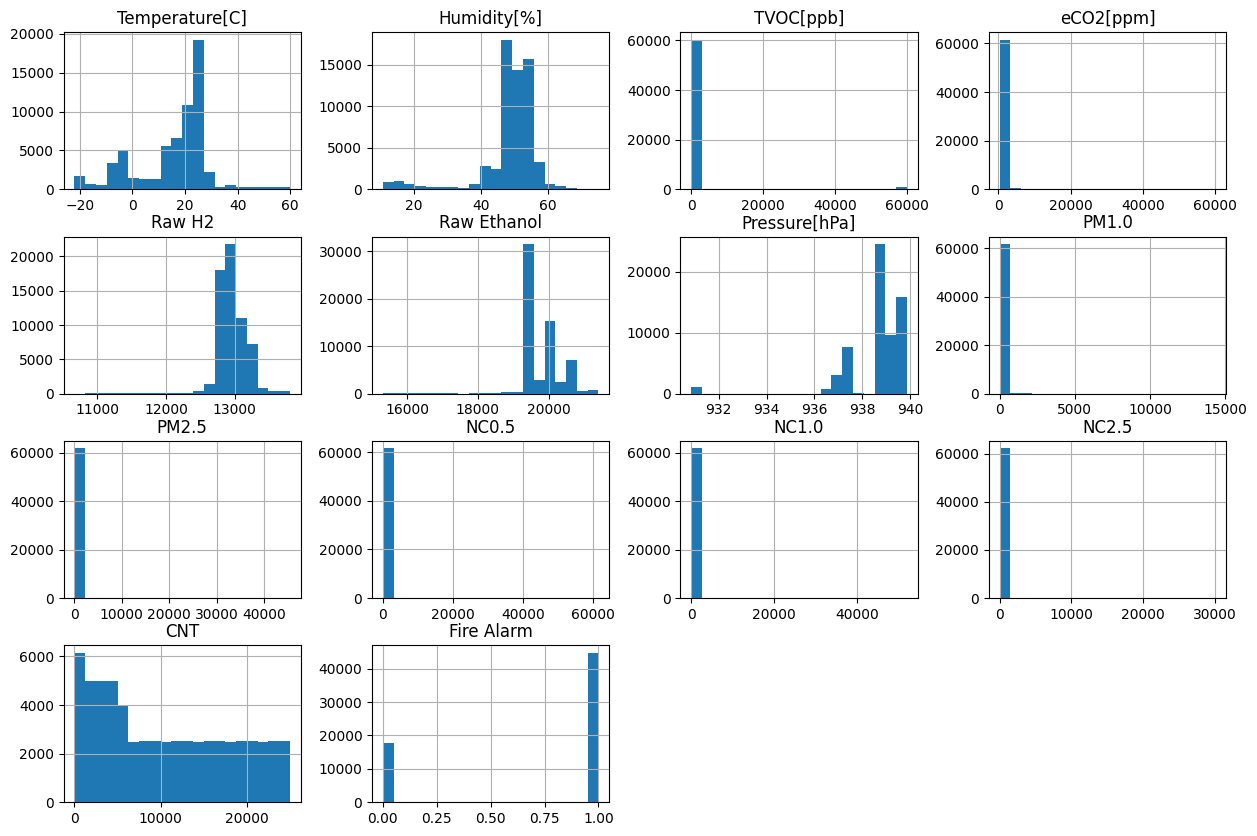

In [ ]:
# Visualize the distribution of all the features
df.drop(['UTC', 'Unnamed: 0'], axis=1).hist(bins=20, figsize=(15, 10))
plt.show() # dropped those two since they dont hold much meaning for us.



Correlation with Fire Alarm:
Fire Alarm        1.000000
CNT               0.673762
Humidity[%]       0.399846
Pressure[hPa]     0.249797
Raw H2            0.107007
NC2.5            -0.057707
NC1.0            -0.082828
PM2.5            -0.084916
eCO2[ppm]        -0.097006
PM1.0            -0.110552
NC0.5            -0.128118
Temperature[C]   -0.163902
TVOC[ppb]        -0.214743
Raw Ethanol      -0.340652
Unnamed: 0       -0.361351
UTC              -0.389404
Name: Fire Alarm, dtype: float64


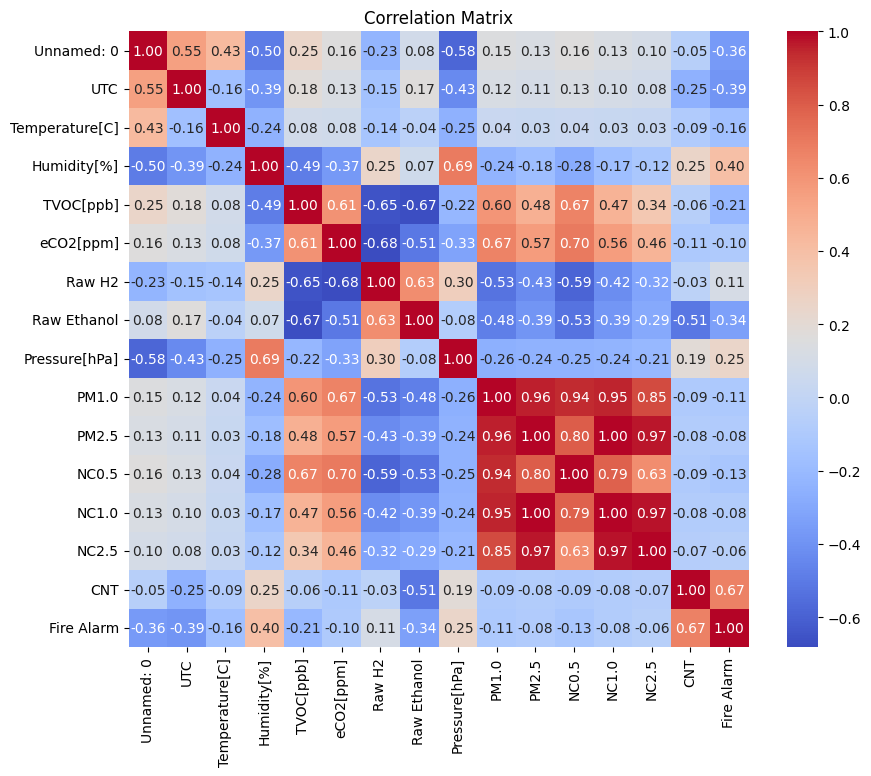

In [ ]:
#Visualize correlation between the features
# Visualize the correlation between features using a heatmap (optional)


#Calculate the correlation matrix
correlation_matrix = df.corr()

# Get the correlation with the 'Fire Alarm' column
fire_alarm_correlation = correlation_matrix['Fire Alarm'].sort_values(ascending=False)

# Print the correlation
print("Correlation with Fire Alarm:")
print(fire_alarm_correlation)

# Visualize the correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### 3. Prepare the Data for Training

In [ ]:
# Separate the features (X) and target (y)
X = df.drop(['CNT','Fire Alarm','UTC', 'Unnamed: 0'],axis=1)   # Features removed bacuase these have are not environmental variables
y = df['Fire Alarm']  # Target (fire alarm, 1 or 0)


In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # changed shuffle = False to stratify=y then models performed great

# Print the shape of the training and testing datasets to verify the split
print(f'Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}')

Training data shape: (50104, 12), Training labels shape: (50104,)
Test data shape: (12526, 12), Test labels shape: (12526,)


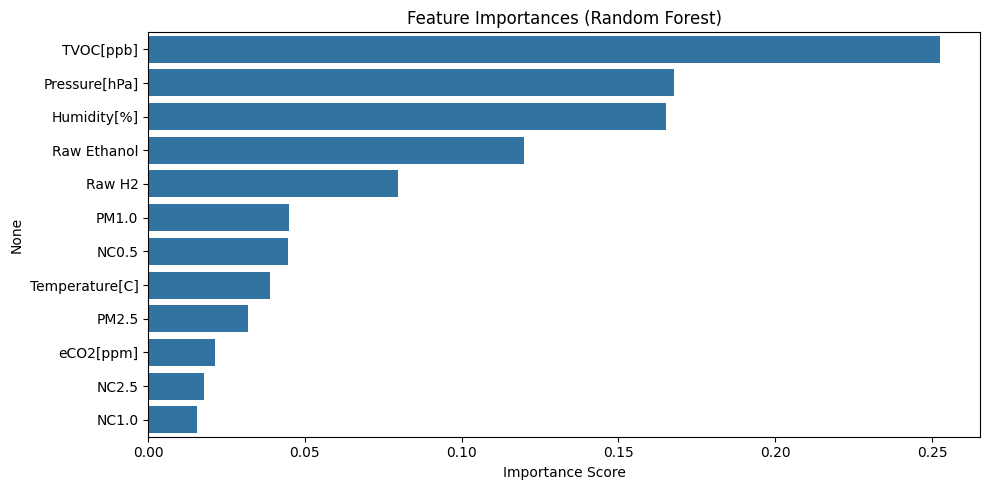

TVOC[ppb]         0.252678
Pressure[hPa]     0.167776
Humidity[%]       0.165121
Raw Ethanol       0.119787
Raw H2            0.079629
PM1.0             0.044938
NC0.5             0.044534
Temperature[C]    0.038948
PM2.5             0.031799
eCO2[ppm]         0.021425
NC2.5             0.017667
NC1.0             0.015697
dtype: float64


In [ ]:
# Quick RF fit just to check feature importance
rf_check = RandomForestClassifier(n_estimators=50, random_state=42)
rf_check.fit(X_train, y_train)

# Plot feature importances
importances = pd.Series(rf_check.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index)
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances_sorted)

In [ ]:

# Dropping features below 1% importance (NC2.5, Temperature)
drop_features = ['NC2.5', 'Temperature[C]']

selected_features = [f for f in X.columns if f not in drop_features]

# Rebuild X_train and X_test with only selected features
fsX_train = X_train[selected_features]
fsX_test = X_test[selected_features]

### 4. Cross Validation Tuning

We decided to include cross validation as our Random Forest model gave an accuracy of 1.0 during presentation. As this may indicate overfitting, we decided to check both models for overfitting.

In [ ]:
#first we do KNN
#commented out since results obtained and used no need to run again each time
'''
knn_results = []

for k in [3, 5, 7, 9, 11]:
    start = time.time()
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    end = time.time()
    knn_results.append((k, scores.mean(), scores.std(), round(end - start, 4)))
    print(f"k={k} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f} | Runtime: {round(end-start, 4)}s")

#Best k selected: 3 (CV Accuracy: 0.9997 ± 0.0002)
'''

'\nknn_results = []\n\nfor k in [3, 5, 7, 9, 11]:\n    start = time.time()\n    model = KNeighborsClassifier(n_neighbors=k)\n    scores = cross_val_score(model, X_train, y_train, cv=5, scoring=\'accuracy\')\n    end = time.time()\n    knn_results.append((k, scores.mean(), scores.std(), round(end - start, 4)))\n    print(f"k={k} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f} | Runtime: {round(end-start, 4)}s")\n\n#Best k selected: 3 (CV Accuracy: 0.9997 ± 0.0002)\n'

In [ ]:
print("=== Random Forest Cross Validation Tuning ===\n")
#commented out since results obtained and used no need to run again each time
'''
rf_results = []

for n in [10, 50, 100, 200]:
    for depth in [5, 10, 20, None]:
        start = time.time()
        model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        end = time.time()
        depth_label = str(depth) if depth is not None else "None"
        rf_results.append((n, depth_label, scores.mean(), scores.std(), round(end - start, 4)))
        print(f"n={n}, depth={depth_label} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f} | Runtime: {round(end-start, 4)}s")

#Best RF selected: n=50, depth=10 (CV Accuracy: 0.9999 ± 0.0001)
'''

=== Random Forest Cross Validation Tuning ===



'\nrf_results = []\n\nfor n in [10, 50, 100, 200]:\n    for depth in [5, 10, 20, None]:\n        start = time.time()\n        model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)\n        scores = cross_val_score(model, X_train, y_train, cv=5, scoring=\'accuracy\')\n        end = time.time()\n        depth_label = str(depth) if depth is not None else "None"\n        rf_results.append((n, depth_label, scores.mean(), scores.std(), round(end - start, 4)))\n        print(f"n={n}, depth={depth_label} | CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f} | Runtime: {round(end-start, 4)}s")\n\n#Best RF selected: n=50, depth=10 (CV Accuracy: 0.9999 ± 0.0001)\n'

### 5. Train both models

we use the best values determined from cross validation here.

And we apply Feature selection

In [ ]:
# Train final KNN
start = time.time()
knn_final = KNeighborsClassifier(n_neighbors=3)
knn_final.fit(X_train, y_train)
knn_train_time = round(time.time() - start, 4)

# Train final RF
start = time.time()
rf_final = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_final.fit(X_train, y_train)
rf_train_time = round(time.time() - start, 4)

# Check for overfitting by comparing train vs test accuracy
for name, model, train_time in [("KNN", knn_final, knn_train_time), ("Random Forest", rf_final, rf_train_time)]:
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    print(f"\n{name}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Gap:            {gap:.4f} {'(no overfitting)' if gap < 0.005 else '(possible overfitting)'}")
    print(f"  Training Time:  {train_time}s")


KNN
  Train Accuracy: 0.9998
  Test Accuracy:  0.9996
  Gap:            0.0002 (no overfitting)
  Training Time:  0.1064s

Random Forest
  Train Accuracy: 1.0000
  Test Accuracy:  0.9998
  Gap:            0.0001 (no overfitting)
  Training Time:  2.8513s


In [ ]:
#now with fs

# Train FS KNN
start = time.time()
fs_knn_final = KNeighborsClassifier(n_neighbors=3)
fs_knn_final.fit(fsX_train, y_train)
fs_knn_train_time = round(time.time() - start, 4)

# Train FS RF
start = time.time()
fs_rf_final = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
fs_rf_final.fit(fsX_train, y_train)
fs_rf_train_time = round(time.time() - start, 4)

# Check for overfitting
for name, model, train_time in [("KNN (FS)", fs_knn_final, fs_knn_train_time), ("Random Forest (FS)", fs_rf_final, fs_rf_train_time)]:
    train_acc = model.score(fsX_train, y_train)
    test_acc = model.score(fsX_test, y_test)
    gap = train_acc - test_acc
    print(f"\n{name}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Gap:            {gap:.4f} {'(no overfitting)' if gap < 0.005 else '(possible overfitting)'}")
    print(f"  Training Time:  {train_time}s")


KNN (FS)
  Train Accuracy: 0.9998
  Test Accuracy:  0.9995
  Gap:            0.0003 (no overfitting)
  Training Time:  0.0898s

Random Forest (FS)
  Train Accuracy: 1.0000
  Test Accuracy:  0.9999
  Gap:            0.0001 (no overfitting)
  Training Time:  2.603s


### 6. Print Results of Models

Since we notice no overfitting it is safe to now print results for both models.

In [ ]:
result = pd.DataFrame(columns=['Classifier', 'Precision', 'Recall', 'F1 Score',
                                'True Negative', 'False Positive',
                                'False Negative', 'True Positive', 'Accuracy (%)', 'Training Time (s)'])

In [ ]:
# KNN Predictions
knn_pred = knn_final.predict(X_test)

knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_accuracy = knn_final.score(X_test, y_test)
tn, fp, fn, tp = confusion_matrix(y_test, knn_pred).ravel()

print("KNN")
print(f"Accuracy: {knn_accuracy*100:.6f}%")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1 Score:  {knn_f1:.4f}")

result.loc["KNN"] = ["K-Nearest Neighbors", round(knn_precision,4), round(knn_recall,4),
                     round(knn_f1,4), tn, fp, fn, tp, round(knn_accuracy*100, 6), knn_train_time]

KNN
Accuracy: 99.960083%
Precision: 0.9994
Recall:    1.0000
F1 Score:  0.9997


In [ ]:
# Random Forest Predictions
rf_pred = rf_final.predict(X_test)

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_accuracy = rf_final.score(X_test, y_test)
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

print("RF")
print(f"Accuracy: {rf_accuracy*100:.6f}%")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")


result.loc["RF"] = ["Random Forest", round(rf_precision,4), round(rf_recall,4),
                    round(rf_f1,4), tn, fp, fn, tp, round(rf_accuracy*100, 6), rf_train_time]

RF
Accuracy: 99.984033%
Precision: 0.9998
Recall:    1.0000
F1 Score:  0.9999


In [ ]:
# KNN (FS) Predictions
fs_knn_pred = fs_knn_final.predict(fsX_test)

fs_knn_precision = precision_score(y_test, fs_knn_pred)
fs_knn_recall = recall_score(y_test, fs_knn_pred)
fs_knn_f1 = f1_score(y_test, fs_knn_pred)
fs_knn_accuracy = fs_knn_final.score(fsX_test, y_test)
tn, fp, fn, tp = confusion_matrix(y_test, fs_knn_pred).ravel()

print("KNN FS")
print(f"Accuracy: {fs_knn_accuracy*100:.6f}%")
print(f"Precision: {fs_knn_precision:.4f}")
print(f"Recall:    {fs_knn_recall:.4f}")
print(f"F1 Score:  {fs_knn_f1:.4f}")

result.loc["KNN (FS)"] = ["K-Nearest Neighbors (FS)", round(fs_knn_precision,4), round(fs_knn_recall,4),
                           round(fs_knn_f1,4), tn, fp, fn, tp, round(fs_knn_accuracy*100, 6), fs_knn_train_time]

KNN FS
Accuracy: 99.952100%
Precision: 0.9993
Recall:    1.0000
F1 Score:  0.9997


In [ ]:
# Random Forest (FS) Predictions
fs_rf_pred = fs_rf_final.predict(fsX_test)

fs_rf_precision = precision_score(y_test, fs_rf_pred)
fs_rf_recall = recall_score(y_test, fs_rf_pred)
fs_rf_f1 = f1_score(y_test, fs_rf_pred)
fs_rf_accuracy = fs_rf_final.score(fsX_test, y_test)
tn, fp, fn, tp = confusion_matrix(y_test, fs_rf_pred).ravel()

print("RF FS")
print(f"Accuracy: {fs_rf_accuracy*100:.6f}%")
print(f"Precision: {fs_rf_precision:.4f}")
print(f"Recall:    {fs_rf_recall:.4f}")
print(f"F1 Score:  {fs_rf_f1:.4f}")

result.loc["RF (FS)"] = ["Random Forest (FS)", round(fs_rf_precision,4), round(fs_rf_recall,4),
                          round(fs_rf_f1,4), tn, fp, fn, tp, round(fs_rf_accuracy*100, 6), fs_rf_train_time]

RF FS
Accuracy: 99.992017%
Precision: 0.9999
Recall:    1.0000
F1 Score:  0.9999


### 7. Visualize Results of Models


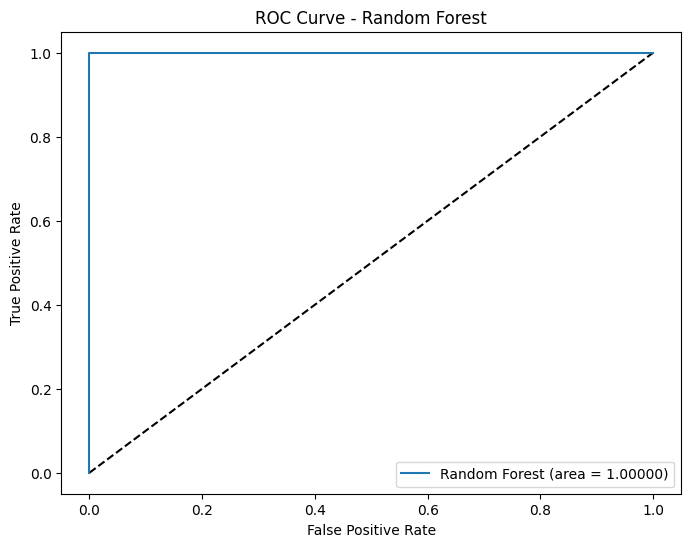

In [ ]:
#rf roc curve
rf_pred_proba = rf_final.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Random Forest (area = {:.5f})'.format(roc_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='best')
plt.show()



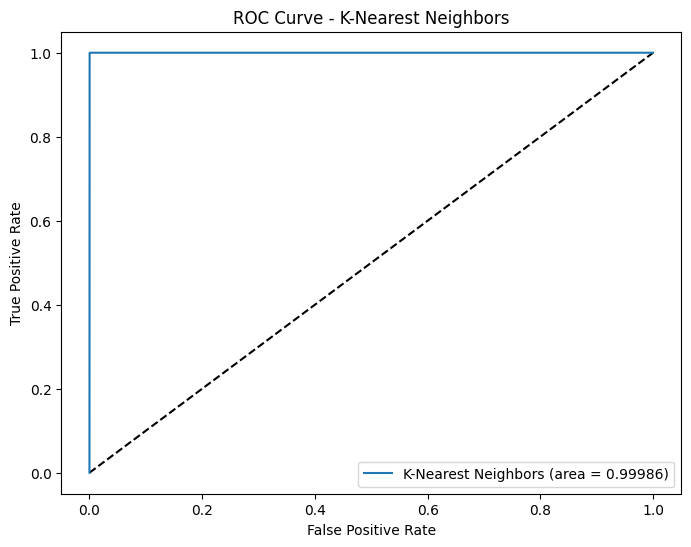

In [ ]:
#knn roc curve
knn_pred_proba = knn_final.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, knn_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='K-Nearest Neighbors (area = {:.5f})'.format(roc_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - K-Nearest Neighbors')
plt.legend(loc='best')
plt.show()

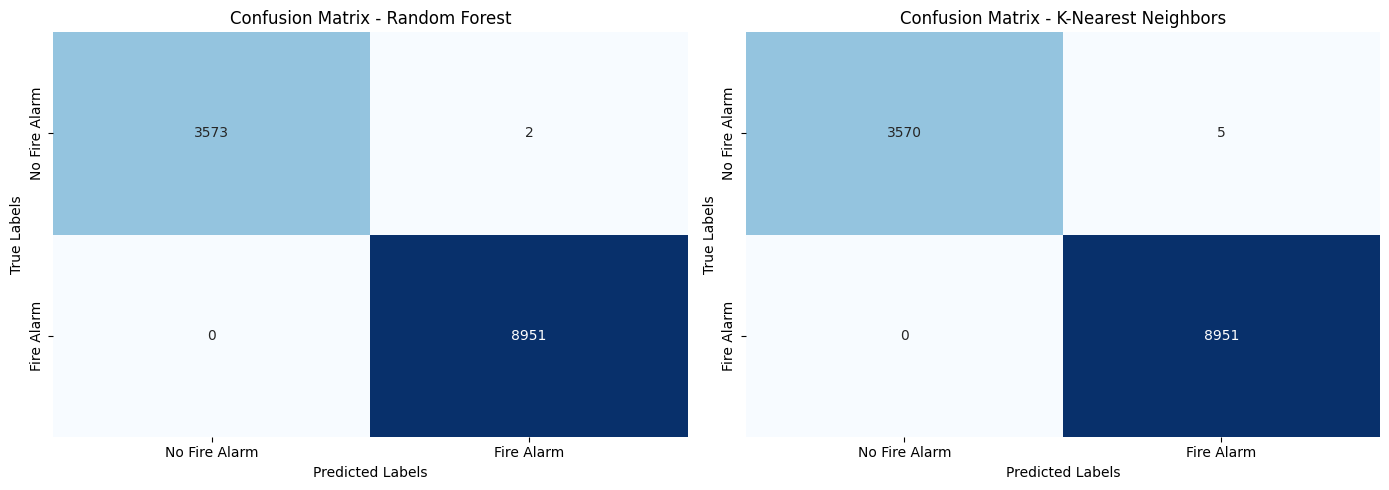

In [ ]:
#confusion matrix for both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [("Random Forest", rf_final), ("K-Nearest Neighbors", knn_final)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Fire Alarm', 'Fire Alarm'],
                yticklabels=['No Fire Alarm', 'Fire Alarm'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')

plt.tight_layout()
plt.show()

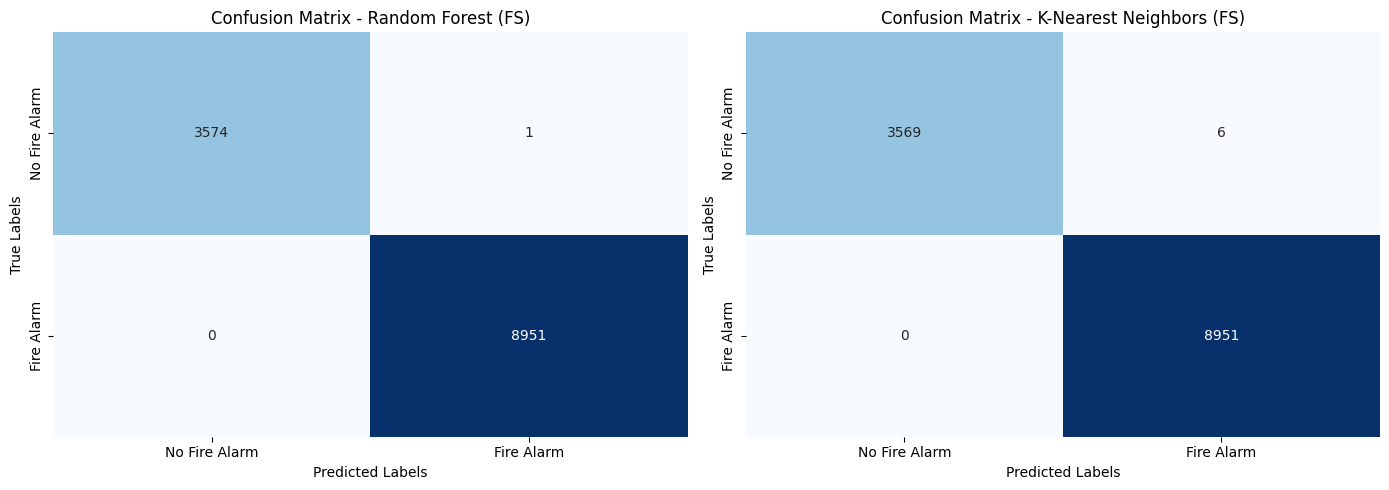

In [ ]:
#confusion matrix for fs models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [("Random Forest (FS)", fs_rf_final), ("K-Nearest Neighbors (FS)", fs_knn_final)]):
    y_pred = model.predict(fsX_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Fire Alarm', 'Fire Alarm'],
                yticklabels=['No Fire Alarm', 'Fire Alarm'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')

plt.tight_layout()
plt.show()
